# Multi-Channel CNN for Cell Type Classification

This notebook trains a 1-D convolutional neural network that classifies V1 excitatory neurons into **fine-grained cell types** (23P, 4P, 5P-IT, 5P-ET, 6P-IT, 6P-CT) using **multi-channel time-series inputs**.

The pipeline is identical to `CNN_multichannel.ipynb` (layer classification) — same 12-channel input tensor, same train/test split strategy, same CNN architectures — with the sole change that the prediction target is `cell_type` instead of `layer`.

Each sample is a tensor of shape `(C, T)` where `T` is the shared time axis and `C = 12` channels:

| Channel | Source | Description |
|---|---|---|
| 0 | Neural response | Z-scored calcium/voltage trace |
| 1 | Stimulus | Per-frame mean luminance (`stim_mean`) |
| 2 | Stimulus | Per-frame pixel std / contrast (`stim_std`) |
| 3 | Stimulus | Frame-to-frame motion energy (`stim_motion`) |
| 4 | Stimulus | Spatial gradient energy (`stim_grad`) |
| 5 | Stimulus | High-gradient edge fraction (`stim_edge_frac`) |
| 6 | Stimulus | Centre-surround contrast (`stim_center_surround`) |
| 7 | Stimulus | Normalised contrast (`stim_norm_contrast`) |
| 8 | Behaviour | Treadmill velocity |
| 9 | Behaviour | Pupil x-position |
| 10 | Behaviour | Pupil y-position |
| 11 | Behaviour | Pupil size |

Neurons are split train/test **by identity** (not by trial) to prevent leakage.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os
import warnings
import importlib
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Locate workspace root ─────────────────────────────────────────────────────
def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root.')

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TOMMY_DIR = Path('..').resolve()
if str(TOMMY_DIR) not in sys.path:
    sys.path.insert(0, str(TOMMY_DIR))

print(f'Workspace root: {ROOT}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE


In [2]:
# ── Load structural metadata ──────────────────────────────────────────────────
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1',
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break

if unit_id_col is None:
    raise ValueError(f'No usable neuron index column. Available: {list(matched.columns)}')

print(f'Matched neurons: {len(matched)}')
print(f'Unit id column: {unit_id_col}')
print('Cell type distribution:')
print(matched['cell_type'].value_counts(dropna=False).sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 90733.32it/s]


Matched neurons: 13044
Unit id column: functional_unit_id
Cell type distribution:
cell_type
23P      6287
4P       4178
5P-ET     560
5P-IT    1548
5P-NP      39
6P-CT     150
6P-IT     282


In [3]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'No functional H5 found. Tried: {H5_CANDIDATES}')

print(f'Using functional file: {functional_path}')
funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Session/scan keys available: {len(scan_df)}')

Using functional file: c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan keys available: 14


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def zscore_1d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)


def resample_to(arr: np.ndarray, target_len: int) -> np.ndarray:
    """Linearly resample a 1-D array to exactly target_len points."""
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == target_len:
        return arr
    old_idx = np.linspace(0, 1, arr.size)
    new_idx = np.linspace(0, 1, target_len)
    return np.interp(new_idx, old_idx, arr).astype(np.float32)


def extract_stim_channels(clip: np.ndarray, target_len: int) -> np.ndarray:
    """
    Extract 7 per-frame stimulus feature time series from a (F, H, W) clip
    and resample each to target_len.
    Returns array of shape (7, target_len), each row z-scored.
    """
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8

    pix = frames.reshape(F, -1)
    mean_intensity = pix.mean(axis=1)
    std_intensity  = pix.std(axis=1)

    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.0], d.reshape(F - 1, -1).mean(axis=1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)

    grad_energy   = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx * gx + gy * gy)
        grad_energy[i]   = gm.mean()
        thr = np.percentile(gm, 85)
        edge_fraction[i] = (gm > thr).mean()

    h0, h1 = H // 4, (3 * H) // 4
    w0, w1 = W // 4, (3 * W) // 4
    center = frames[:, h0:h1, w0:w1]
    center_mean   = center.reshape(F, -1).mean(axis=1)
    surround_sum  = pix.sum(axis=1) - center.reshape(F, -1).sum(axis=1)
    surround_n    = (H * W) - ((h1 - h0) * (w1 - w0))
    surround_mean = surround_sum / max(surround_n, 1)
    center_surround = center_mean - surround_mean

    norm_contrast = std_intensity / (mean_intensity + eps)

    raw_channels = [
        mean_intensity, std_intensity, motion_energy,
        grad_energy, edge_fraction, center_surround, norm_contrast,
    ]
    result = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate(raw_channels):
        resampled = resample_to(ch, target_len)
        result[i] = zscore_1d(resampled)
    return result


def extract_behaviour_channels(trial: dict, target_len: int) -> np.ndarray:
    """
    Extract treadmill + pupil channels from a trial dict.
    Returns array of shape (4, target_len): [treadmill, pupil_x, pupil_y, pupil_size].
    NaN values are filled with zero after z-scoring.
    """
    result = np.zeros((4, target_len), dtype=np.float32)

    # ── Treadmill ─────────────────────────────────────────────────────────────
    treadmill = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    treadmill = np.where(np.isfinite(treadmill), treadmill, 0.0)
    result[0] = zscore_1d(resample_to(treadmill, target_len))

    # ── Pupil ─────────────────────────────────────────────────────────────────
    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    if pupil.ndim == 2:
        if pupil.shape[0] == 3 and pupil.shape[1] != 3:
            pass
        elif pupil.shape[1] == 3:
            pupil = pupil.T
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], np.nan)
                ch = np.where(np.isfinite(ch), ch, 0.0)
                result[1 + i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        ch = np.where(np.isfinite(pupil), pupil, 0.0)
        result[3] = zscore_1d(resample_to(ch, target_len))

    return result

In [5]:
# ── Data collection (ONE sample per matched neuron) ───────────────────────────
MAX_TRIALS_PER_SCAN = 8
MIN_TRACE_LEN       = 60
TARGET_LEN          = 300

# N_CHANNELS = 1 (neural) + 7 (stimulus) + 4 (behaviour)
N_CHANNELS = 12

STIM_CHANNEL_NAMES = [
    'stim_mean', 'stim_std', 'stim_motion',
    'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast',
]
BEH_CHANNEL_NAMES  = ['treadmill', 'pupil_x', 'pupil_y', 'pupil_size']
CHANNEL_NAMES      = ['neural_response'] + STIM_CHANNEL_NAMES + BEH_CHANNEL_NAMES

neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col
print(f'Neuron identity column used for one-sample policy: {neuron_key_col}')

neuron_records = {}
clip_cache     = {}

matched_scans = matched[['session', 'scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

for _, srow in scan_candidates.iterrows():
    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    session_neurons = session_neurons.dropna(subset=[unit_id_col, 'cell_type', neuron_key_col])
    session_neurons['cell_type'] = session_neurons['cell_type'].astype(str)
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        cond_hash = hashes[t]
        if cond_hash not in clip_cache:
            clip, _ = funcreader.get_video_data(cond_hash)
            if clip is None:
                clip_cache[cond_hash] = None
            else:
                clip_cache[cond_hash] = extract_stim_channels(clip, TARGET_LEN)

        stim_channels = clip_cache[cond_hash]
        beh_channels  = extract_behaviour_channels(td, TARGET_LEN)
        responses     = td['responses']

        for _, nr in session_neurons.iterrows():
            neuron_key = int(nr[neuron_key_col])
            if neuron_key in neuron_records:
                continue

            cell_type = str(nr['cell_type'])
            fuid      = int(nr[unit_id_col])
            row_idx   = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue

            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            trace = resample_to(trace, TARGET_LEN)
            trace = zscore_1d(trace)

            multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
            multichan[0] = trace
            if stim_channels is not None:
                multichan[1:8] = stim_channels
            multichan[8:12] = beh_channels

            neuron_records[neuron_key] = {
                'neuron_key': neuron_key,
                'cell_type':  cell_type,
                'multichan':  multichan,
                'unit_id':    fuid,
                'session':    session,
                'scan_idx':   scan_idx,
                'trial_idx':  t,
            }

records = list(neuron_records.values())
print(f'Total unique neuron samples collected: {len(records)}')
print('Samples by cell_type:')
print(pd.Series([r['cell_type'] for r in records]).value_counts().sort_index().to_string())

Neuron identity column used for one-sample policy: functional_unit_id
Candidate session/scan pairs: 14
Total unique neuron samples collected: 6563
Samples by cell_type:
23P      2689
4P       2162
5P-ET     423
5P-IT     943
5P-NP      26
6P-CT     113
6P-IT     207


In [6]:
# ── Split neurons train / test ────────────────────────────────────────────────
neuron_df = pd.DataFrame([
    {'neuron_key': r['neuron_key'], 'cell_type': r['cell_type']} for r in records
]).drop_duplicates(subset=['neuron_key'])

# Drop rare cell types (fewer than 20 neurons)
ct_counts   = neuron_df['cell_type'].value_counts()
keep_types  = ct_counts[ct_counts >= 20].index.tolist()
neuron_df   = neuron_df[neuron_df['cell_type'].isin(keep_types)].copy()
print('Neurons per cell_type (after rare-class filter):')
print(neuron_df['cell_type'].value_counts().sort_index().to_string())

TARGET_TRAIN_SAMPLES = 6000
test_size    = 0.25
total_target = int(round(TARGET_TRAIN_SAMPLES / (1 - test_size)))

if len(neuron_df) > total_target:
    _, neuron_df = train_test_split(
        neuron_df,
        train_size=total_target,
        random_state=42,
        stratify=neuron_df['cell_type'].values,
    )
    neuron_df = neuron_df.reset_index(drop=True)

print(f'Total neurons used: {len(neuron_df)} (target total: {total_target})')

train_neurons, test_neurons = train_test_split(
    neuron_df['neuron_key'].values,
    test_size=test_size,
    random_state=42,
    stratify=neuron_df['cell_type'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)
print(f'Train neurons/samples: {len(train_set)} | Test neurons/samples: {len(test_set)}')

enc = LabelEncoder()
enc.fit(neuron_df['cell_type'])


def build_split(neuron_keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in neuron_keys_set or r['cell_type'] not in keep_types:
            continue
        X.append(r['multichan'])
        y.append(r['cell_type'])
        uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)


X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)

print(f'\nTrain samples: {X_train.shape} | Test samples: {X_test.shape}')
print(f'Input shape per sample: channels={X_train.shape[1]}, time={X_train.shape[2]}')
print('Train class distribution:')
print(pd.Series(enc.inverse_transform(y_train)).value_counts().sort_index().to_string())
print('Test class distribution:')
print(pd.Series(enc.inverse_transform(y_test)).value_counts().sort_index().to_string())

Neurons per cell_type (after rare-class filter):
cell_type
23P      2689
4P       2162
5P-ET     423
5P-IT     943
5P-NP      26
6P-CT     113
6P-IT     207
Total neurons used: 6563 (target total: 8000)
Train neurons/samples: 4922 | Test neurons/samples: 1641

Train samples: (4922, 12, 300) | Test samples: (1641, 12, 300)
Input shape per sample: channels=12, time=300
Train class distribution:
23P      2017
4P       1621
5P-ET     317
5P-IT     707
5P-NP      20
6P-CT      85
6P-IT     155
Test class distribution:
23P      672
4P       541
5P-ET    106
5P-IT    236
5P-NP      6
6P-CT     28
6P-IT     52


In [7]:
# ── PyTorch setup ─────────────────────────────────────────────────────────────
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
    ])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

BATCH_SIZE = 128

def make_loader(X, y, shuffle):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')
print(f'Classes: {list(enc.classes_)}')

PyTorch 2.11.0+cpu | device: cpu
Train batches: 39 | Test batches: 13
Classes: ['23P', '4P', '5P-ET', '5P-IT', '5P-NP', '6P-CT', '6P-IT']


In [ ]:
# ── Multi-channel CNN architecture ───────────────────────────────────────────

class MultiChannelShallowCNN(nn.Module):
    """
    Shallow 1-D CNN for multi-channel input.
    Input shape: (B, C, T) where C = N_CHANNELS, T = TARGET_LEN.

    Architecture:
      Block 1: Conv1d(C  →  64, k=7) → BN → ReLU → MaxPool(2)
      Block 2: Conv1d(64 → 128, k=5) → BN → ReLU → MaxPool(2)
      Block 3: Conv1d(128→ 256, k=3) → BN → ReLU → MaxPool(2)
      Head:    Flatten → Linear(256·T/8, 256) → ReLU → Dropout → Linear → n_classes
    """
    def __init__(self, in_channels: int, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(64,         128,  kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,        256,  kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.conv(x))


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

shallow_cnn = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
print(f'MultiChannelShallowCNN params: {count_params(shallow_cnn):,}')
print(f'Input shape: (batch, {N_CHANNELS}, {TARGET_LEN})')
print(f'Channels: {CHANNEL_NAMES}')

In [19]:
# ── Training utilities ────────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, *,
                lr=3e-4, weight_decay=1e-4,
                max_epochs=300, patience=100,
                label='model'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs)

    history      = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'[{label}] Early stop at epoch {epoch}')
                break

        print(f'[{label}] Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'[{label}] Restored best checkpoint (val_loss={best_val_loss:.4f})')
    return history


def evaluate(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

In [20]:
# ── Train ShallowCNN ──────────────────────────────────────────────────────────
shallow_cnn = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
history_shallow = train_model(shallow_cnn, train_loader, test_loader, label='ShallowCNN')

[ShallowCNN] Epoch   1 | train=1.9168  val=1.6777  acc=0.231
[ShallowCNN] Epoch   2 | train=1.7157  val=1.6336  acc=0.183
[ShallowCNN] Epoch   3 | train=1.6773  val=1.6139  acc=0.206
[ShallowCNN] Epoch   4 | train=1.6194  val=1.6354  acc=0.308
[ShallowCNN] Epoch   5 | train=1.5491  val=1.6760  acc=0.245
[ShallowCNN] Epoch   6 | train=1.5263  val=1.6353  acc=0.239
[ShallowCNN] Epoch   7 | train=1.5131  val=1.6677  acc=0.278
[ShallowCNN] Epoch   8 | train=1.4538  val=1.7049  acc=0.274
[ShallowCNN] Epoch   9 | train=1.4252  val=1.7270  acc=0.277
[ShallowCNN] Epoch  10 | train=1.3790  val=1.7556  acc=0.307
[ShallowCNN] Epoch  11 | train=1.3448  val=1.7598  acc=0.316
[ShallowCNN] Epoch  12 | train=1.2794  val=1.7957  acc=0.301
[ShallowCNN] Epoch  13 | train=1.2745  val=1.8106  acc=0.305
[ShallowCNN] Epoch  14 | train=1.2205  val=1.8623  acc=0.362
[ShallowCNN] Epoch  15 | train=1.1479  val=1.9784  acc=0.337
[ShallowCNN] Epoch  16 | train=1.1503  val=1.9094  acc=0.363
[ShallowCNN] Epoch  17 |

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(history_shallow['train_loss'], label='train')
ax_loss.plot(history_shallow['val_loss'],   label='val')
ax_loss.set_title('ShallowCNN — loss')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Cross-entropy')
ax_loss.legend()

ax_acc.plot(history_shallow['val_acc'], color='steelblue')
ax_acc.axhline(1 / n_classes, color='grey', linestyle='--', label=f'chance ({1/n_classes:.2f})')
ax_acc.set_title('ShallowCNN — val accuracy')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')
ax_acc.legend()

plt.tight_layout()
plt.show()

In [29]:
# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = evaluate(shallow_cnn, test_loader)

print('── ShallowCNN (multi-channel, cell_type) ──')
print(classification_report(y_test, y_pred, target_names=enc.classes_))
print(f'Accuracy:          {accuracy_score(y_test, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}')
print(f'Macro F1:          {f1_score(y_test, y_pred, average="macro"):.3f}')

── ShallowCNN (multi-channel, cell_type) ──
              precision    recall  f1-score   support

         23P       0.77      0.13      0.23       672
          4P       0.67      0.21      0.32       541
       5P-ET       0.13      0.50      0.21       106
       5P-IT       0.20      0.26      0.23       236
       5P-NP       0.01      0.33      0.02         6
       6P-CT       0.04      0.64      0.08        28
       6P-IT       0.00      0.00      0.00        52

    accuracy                           0.21      1641
   macro avg       0.26      0.30      0.15      1641
weighted avg       0.58      0.21      0.25      1641

Accuracy:          0.206
Balanced accuracy: 0.297
Macro F1:          0.155


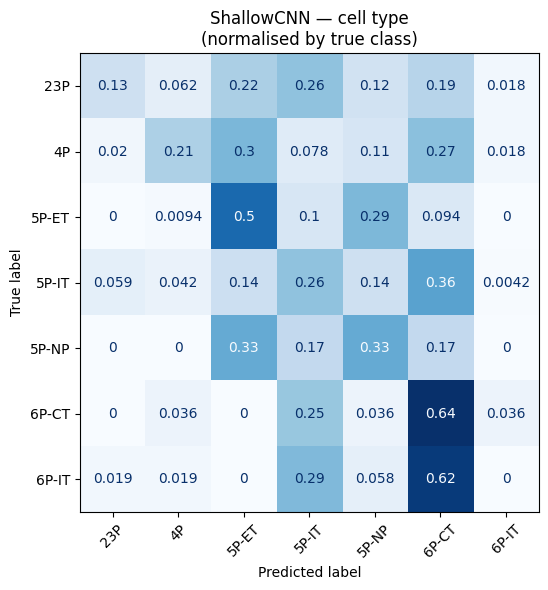

In [30]:
# ── Cell-type confusion matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=enc.classes_,
    xticks_rotation=45,
    cmap='Blues',
    normalize='true',
    colorbar=False,
    ax=ax,
)
ax.set_title('ShallowCNN — cell type\n(normalised by true class)')
plt.tight_layout()
plt.show()

── Layer-level metrics (derived from cell-type predictions) ──
              precision    recall  f1-score   support

        L2/3       0.77      0.13      0.23       672
          L4       0.67      0.21      0.32       541
          L5       0.25      0.65      0.36       348
          L6       0.12      0.64      0.20        80

    accuracy                           0.29      1641
   macro avg       0.45      0.41      0.28      1641
weighted avg       0.60      0.29      0.28      1641

Accuracy:          0.293
Balanced accuracy: 0.408
Macro F1:          0.276


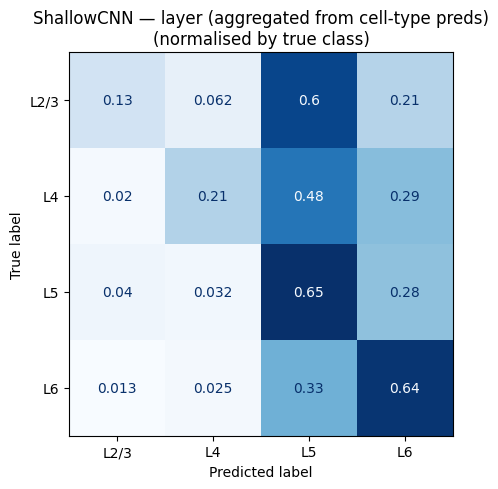

In [31]:
# ── Layer-level confusion matrix ──────────────────────────────────────────────
# Each cell type encodes its layer in its leading digit(s):
#   23P → L2/3 | 4P → L4 | 5P-* → L5 | 6P-* → L6
def cell_type_to_layer(ct: str) -> str:
    if ct.startswith('2'):
        return 'L2/3'
    elif ct.startswith('4'):
        return 'L4'
    elif ct.startswith('5'):
        return 'L5'
    elif ct.startswith('6'):
        return 'L6'
    return 'other'

# Map encoded integer labels → cell type names → layer strings
ct_true = enc.inverse_transform(y_test)
ct_pred = enc.inverse_transform(y_pred)

layer_true = np.array([cell_type_to_layer(c) for c in ct_true])
layer_pred = np.array([cell_type_to_layer(c) for c in ct_pred])

layer_labels = ['L2/3', 'L4', 'L5', 'L6']

print('── Layer-level metrics (derived from cell-type predictions) ──')
print(classification_report(layer_true, layer_pred, labels=layer_labels))
print(f'Accuracy:          {accuracy_score(layer_true, layer_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(layer_true, layer_pred):.3f}')
print(f'Macro F1:          {f1_score(layer_true, layer_pred, labels=layer_labels, average="macro"):.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    layer_true, layer_pred,
    labels=layer_labels,
    cmap='Blues',
    normalize='true',
    colorbar=False,
    ax=ax,
)
ax.set_title('ShallowCNN — layer (aggregated from cell-type preds)\n(normalised by true class)')
plt.tight_layout()
plt.show()

In [32]:
# ── Per-neuron majority-vote ───────────────────────────────────────────────────
from scipy.stats import mode as scipy_mode

def per_neuron_majority_vote(model, X, y, uids):
    loader = make_loader(X, y, shuffle=False)
    preds  = evaluate(model, loader)

    neuron_preds = {}
    neuron_true  = {}
    for uid, pred, true in zip(uids, preds, y):
        neuron_preds.setdefault(uid, []).append(pred)
        neuron_true[uid] = true

    voted_preds, voted_true = [], []
    for uid in neuron_preds:
        majority = scipy_mode(neuron_preds[uid], keepdims=False).mode
        voted_preds.append(majority)
        voted_true.append(neuron_true[uid])

    return np.array(voted_true), np.array(voted_preds)


vt, vp = per_neuron_majority_vote(shallow_cnn, X_test, y_test, uids_test)
print('── ShallowCNN per-neuron majority-vote ──')
print(f'Neurons evaluated: {len(vt)}')
print(f'Accuracy:          {accuracy_score(vt, vp):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(vt, vp):.3f}')
print(f'Macro F1:          {f1_score(vt, vp, average="macro"):.3f}')
print(classification_report(vt, vp, target_names=enc.classes_))

── ShallowCNN per-neuron majority-vote ──
Neurons evaluated: 1641
Accuracy:          0.206
Balanced accuracy: 0.297
Macro F1:          0.155
              precision    recall  f1-score   support

         23P       0.77      0.13      0.23       672
          4P       0.67      0.21      0.32       541
       5P-ET       0.13      0.50      0.21       106
       5P-IT       0.20      0.26      0.23       236
       5P-NP       0.01      0.33      0.02         6
       6P-CT       0.04      0.64      0.08        28
       6P-IT       0.00      0.00      0.00        52

    accuracy                           0.21      1641
   macro avg       0.26      0.30      0.15      1641
weighted avg       0.58      0.21      0.25      1641



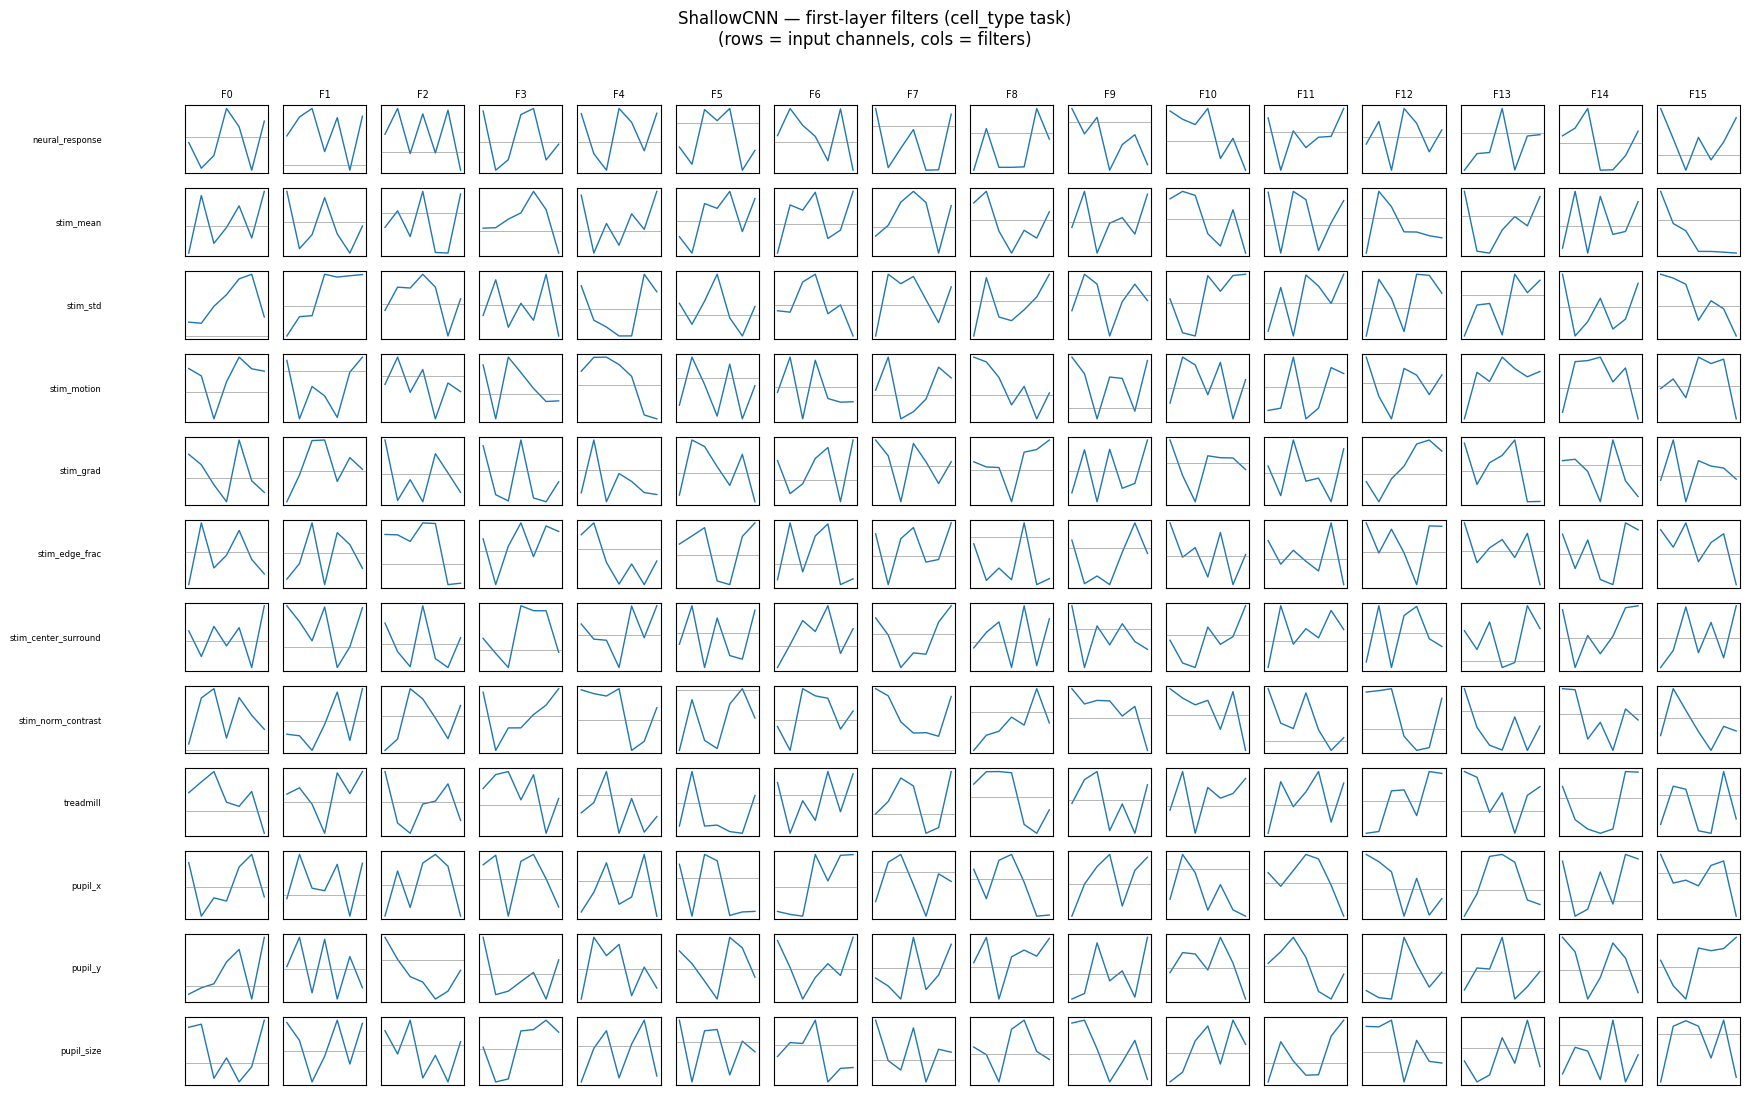

In [33]:
# ── Visualise first-layer filters of ShallowCNN ───────────────────────────────
first_conv = shallow_cnn.conv[0]  # Conv1d(N_CHANNELS, 64, kernel_size=7)
filters    = first_conv.weight.detach().cpu().numpy()  # (64, N_CHANNELS, 7)

n_filters_to_show = min(16, filters.shape[0])
fig, axes = plt.subplots(N_CHANNELS, n_filters_to_show,
                          figsize=(n_filters_to_show * 1.1, N_CHANNELS * 0.9))

for ch_idx in range(N_CHANNELS):
    for f_idx in range(n_filters_to_show):
        ax = axes[ch_idx, f_idx]
        ax.plot(filters[f_idx, ch_idx], linewidth=1)
        ax.axhline(0, color='grey', linewidth=0.4)
        ax.set_xticks([])
        ax.set_yticks([])
        if f_idx == 0:
            ax.set_ylabel(CHANNEL_NAMES[ch_idx], fontsize=6, rotation=0,
                          ha='right', va='center', labelpad=60)
        if ch_idx == 0:
            ax.set_title(f'F{f_idx}', fontsize=7)

fig.suptitle('ShallowCNN — first-layer filters (cell_type task)\n(rows = input channels, cols = filters)',
             y=1.01)
plt.tight_layout()
plt.show()

## Results & Discussion

### Task description

This notebook asks whether the same 12-channel multi-channel CNN that successfully classified cortical **layers** (L2/3, L4, L5, L6) can also classify **fine-grained cell types** (23P, 4P, 5P-IT, 5P-ET, 6P-IT, 6P-CT) from the same functional input.

Cell type in the MICrONS dataset is derived from structural morphology and gene-expression proxies (AIBS classification), not directly from functional recordings — so the task is asking whether **electrophysiological response profiles encode cell-type identity** in addition to laminar position.

### Relationship between `layer` and `cell_type`

The two labels are strongly correlated:

| Cell type | Dominant layer |
|---|---|
| 23P  | L2/3 |
| 4P   | L4   |
| 5P-IT / 5P-ET / 5P-NP | L5 |
| 6P-IT / 6P-CT | L6 |

Because of this near-one-to-one mapping, a cell-type classifier will face a very similar signal-to-noise ratio as the layer classifier.  The harder sub-problem is distinguishing **within-layer subtypes** (e.g. 5P-IT vs 5P-ET both in L5, or 6P-IT vs 6P-CT both in L6).

### What to look for

| Metric | Expectation |
|---|---|
| **Overall accuracy** | Likely similar to the layer task (~80%) if the model learns layer-level features; lower if it is confused by within-layer subtypes |
| **5P-IT vs 5P-ET confusion** | These two share L5 but differ in projection targets — the functional differences may be subtle |
| **6P-IT vs 6P-CT confusion** | Both in L6, likely the hardest pair |
| **Balanced accuracy** | Key metric given strong class imbalance (23P ≈ 47% of data) |

### Limitations

- **Class imbalance is more severe here.** 23P alone accounts for ~47% of matched V1 excitatory neurons; 6P-CT and 6P-IT are each < 5%. Class-weighted loss partially compensates but rare-class performance will remain noisy.
- **Label noise.** Cell type is assigned from structural/transcriptomic data; co-registration errors may introduce mislabelled examples in the functional training set.
- All limitations from the layer notebook (stimulus resampling, pupil NaN filling, trial limit, session-state sharing) apply here equally.